# Zainab Ali Alsharait - 2230006803 - 8FA2
# ARTI 406 - Machine Learning
# Assignment 2: Data Preprocessing
## **Dataset:** Video Game Sales (vgsales.csv)

### Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


### Load the Dataset

In [18]:
df = pd.read_csv('vgsales.csv')

print('Shape:', df.shape)
df.head()

Shape: (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Task 1: Identify Data Quality Issues

#### Check Missing Values

In [19]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).query('`Missing Count` > 0')

print(missing_df)

           Missing Count  Missing (%)
Year                 271         1.63
Publisher             58         0.35


#### Check Duplicates

In [20]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

Duplicate rows: 0


#### Check Data Types & Basic Stats

In [21]:
print(df.dtypes)

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [22]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


### Task 1 – Summary of Data Quality Issues

| Issue | Column(s) | Detail |
|---|---|---|
| Missing values | `Year`, `Publisher` | 271 and 58 missing rows respectively |
| Wrong data type | `Year` | Stored as float64, should be integer |
| Outliers | All sales columns | Max values far exceed the 75th percentile |
| Duplicates | — | No duplicate rows found |

## Task 2 – Missing Value Strategy

In [23]:
print('Shape before:', df.shape)

df_clean = df.dropna(subset=['Year']).copy()
df_clean['Publisher'] = df_clean['Publisher'].fillna('Unknown')
df_clean['Year'] = df_clean['Year'].astype(int)

print('Shape after:', df_clean.shape)
print('\nRemaining missing values:')
print(df_clean.isnull().sum())

Shape before: (16598, 11)
Shape after: (16327, 11)

Remaining missing values:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


### Strategy Justification

- **Year → Row Deletion:** Only 1.63% of rows affected, so data loss is small.
  Filling Year with mean/mode would create fake time patterns that distort analysis.

- **Publisher → Fill with 'Unknown':** Only 0.35% missing. Since it's categorical,
  a neutral label keeps the rows without misattributing games to real publishers.

## Task 3 – Outlier Detection and Handling (IQR)

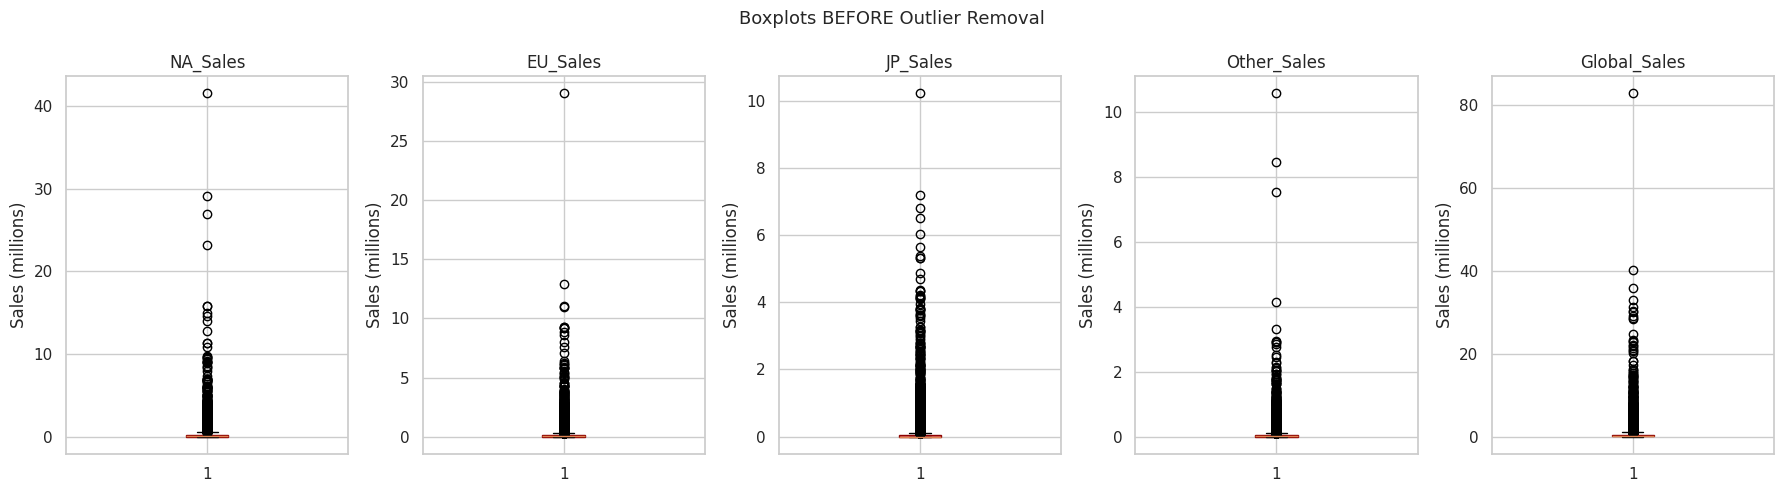

In [24]:
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, sales_cols):
    ax.boxplot(df_clean[col], patch_artist=True,
               boxprops=dict(facecolor='lightcoral', color='darkred'))
    ax.set_title(col)
    ax.set_ylabel('Sales (millions)')

plt.suptitle('Boxplots BEFORE Outlier Removal', fontsize=13)
plt.tight_layout()
plt.show()

#### calculate IQR bounds and remove outliers

In [25]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

mask = pd.Series([True] * len(df_clean), index=df_clean.index)

for col in sales_cols:
    lo, hi = iqr_bounds(df_clean[col])
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    col_mask = (df_clean[col] >= lo) & (df_clean[col] <= hi)
    mask = mask & col_mask
    print(f'{col}: Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}, Lower={lo:.3f}, Upper={hi:.3f}, Outliers={n_out}')

df_no_outliers = df_clean[mask].copy()
print(f'\nRows before: {len(df_clean):,}  →  After: {len(df_no_outliers):,}')

NA_Sales: Q1=0.000, Q3=0.240, IQR=0.240, Lower=-0.360, Upper=0.600, Outliers=1660
EU_Sales: Q1=0.000, Q3=0.110, IQR=0.110, Lower=-0.165, Upper=0.275, Outliers=2054
JP_Sales: Q1=0.000, Q3=0.040, IQR=0.040, Lower=-0.060, Upper=0.100, Outliers=2407
Other_Sales: Q1=0.000, Q3=0.040, IQR=0.040, Lower=-0.060, Upper=0.100, Outliers=1645
Global_Sales: Q1=0.060, Q3=0.480, IQR=0.420, Lower=-0.570, Upper=1.110, Outliers=1827

Rows before: 16,327  →  After: 11,801


#### visualize after removal

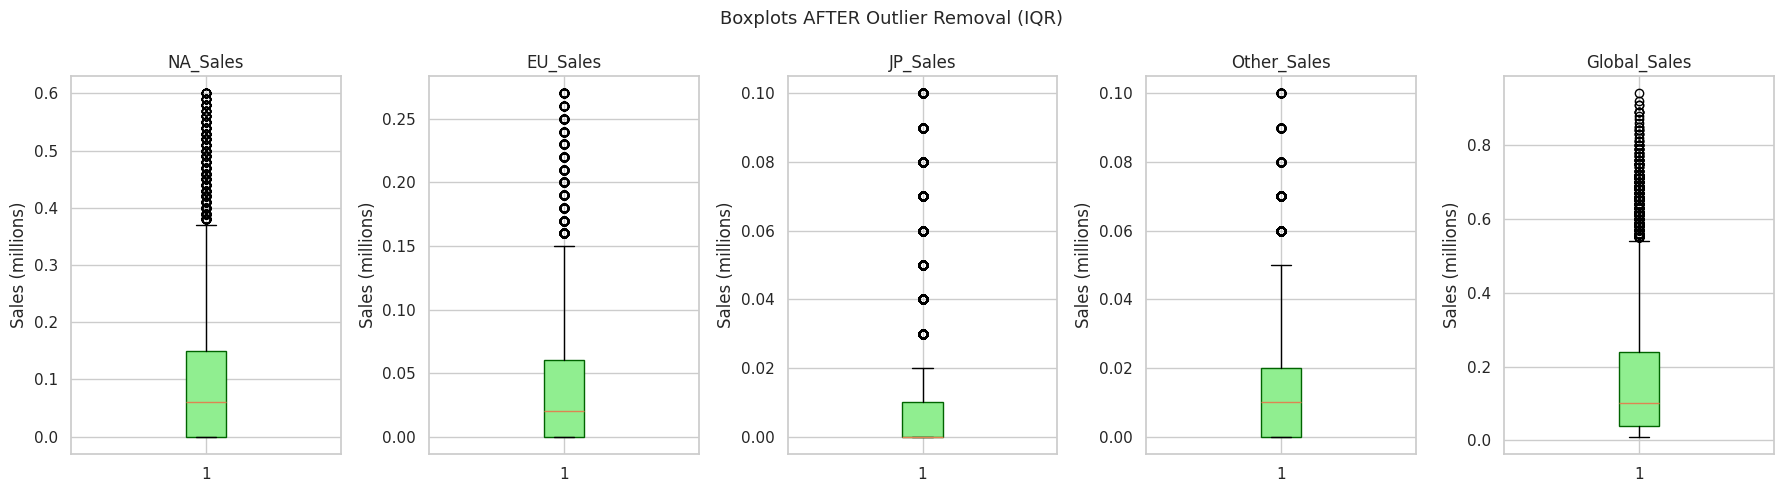

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, sales_cols):
    ax.boxplot(df_no_outliers[col], patch_artist=True,
               boxprops=dict(facecolor='lightgreen', color='darkgreen'))
    ax.set_title(col)
    ax.set_ylabel('Sales (millions)')

plt.suptitle('Boxplots AFTER Outlier Removal (IQR)', fontsize=13)
plt.tight_layout()
plt.show()

### Task 3 – Interpretation
The IQR method identified outliers in all 5 sales columns.
Rows were removed if any sales column exceeded the IQR bounds.
Dataset reduced from 16,327 to 11,801 rows after cleaning.
The boxplots after removal show a much more balanced distribution.

## Task 4 – Normalization (Min-Max and Z-score)

In [27]:
num_features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
X = df_no_outliers[num_features].copy()

# Min-Max Normalization
minmax = MinMaxScaler()
X_minmax = pd.DataFrame(
    minmax.fit_transform(X),
    columns=[f'{c}_minmax' for c in num_features]
)

# Z-score Standardization
zscore = StandardScaler()
X_zscore = pd.DataFrame(
    zscore.fit_transform(X),
    columns=[f'{c}_zscore' for c in num_features]
)

print('Min-Max (first 5 rows):')
print(X_minmax.head())
print('\nZ-score (first 5 rows):')
print(X_zscore.head())

Min-Max (first 5 rows):
   NA_Sales_minmax  EU_Sales_minmax  JP_Sales_minmax  Other_Sales_minmax  \
0         0.850000         0.962963              0.9                 0.8   
1         0.966667         0.962963              0.0                 0.8   
2         0.966667         0.888889              0.1                 0.9   
3         0.950000         0.962963              0.0                 0.8   
4         1.000000         0.814815              0.5                 0.2   

   Global_Sales_minmax  
0             1.000000  
1             0.978495  
2             0.967742  
3             0.967742  
4             0.946237  

Z-score (first 5 rows):
   NA_Sales_zscore  EU_Sales_zscore  JP_Sales_zscore  Other_Sales_zscore  \
0         3.381558         3.712352         3.574521            3.619377   
1         3.960430         3.712352        -0.467968            3.619377   
2         3.960430         3.372449        -0.018802            4.160450   
3         3.877734         3.712352     

####  visualize the difference

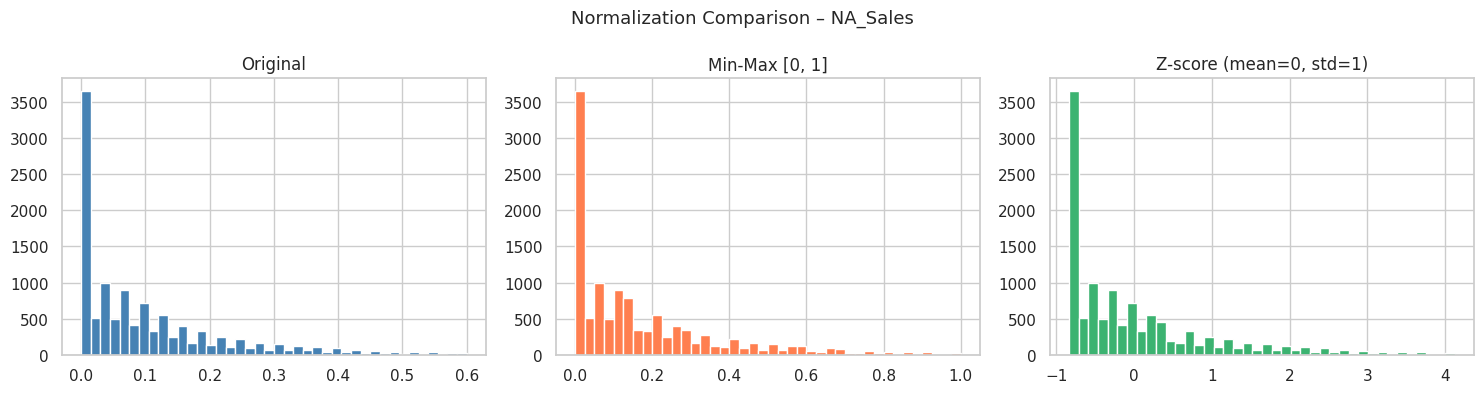

In [28]:
col = 'NA_Sales'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X[col], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Original')

axes[1].hist(X_minmax[f'{col}_minmax'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Min-Max [0, 1]')

axes[2].hist(X_zscore[f'{col}_zscore'], bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Z-score (mean=0, std=1)')

plt.suptitle('Normalization Comparison – NA_Sales', fontsize=13)
plt.tight_layout()
plt.show()

### Task 4 – Interpretation
- **Min-Max:** Scales all values to [0, 1]. Shape of distribution is preserved.
- **Z-score:** Transforms data to mean=0 and std=1. Better for PCA and algorithms
  sensitive to scale. More robust when data still has some spread.

## Task 5 – PCA and Explained Variance

#### fit PCA

In [29]:
pca = PCA()
X_pca = pca.fit_transform(X_zscore)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_summary = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained))],
    'Explained Var (%)': (explained * 100).round(2),
    'Cumulative (%)': (cumulative * 100).round(2)
})

print(pca_summary.to_string(index=False))

 PC  Explained Var (%)  Cumulative (%)
PC1              64.53           64.53
PC2              19.14           83.68
PC3              11.58           95.25
PC4               4.74           99.99
PC5               0.01          100.00


#### visualize with a scree plot

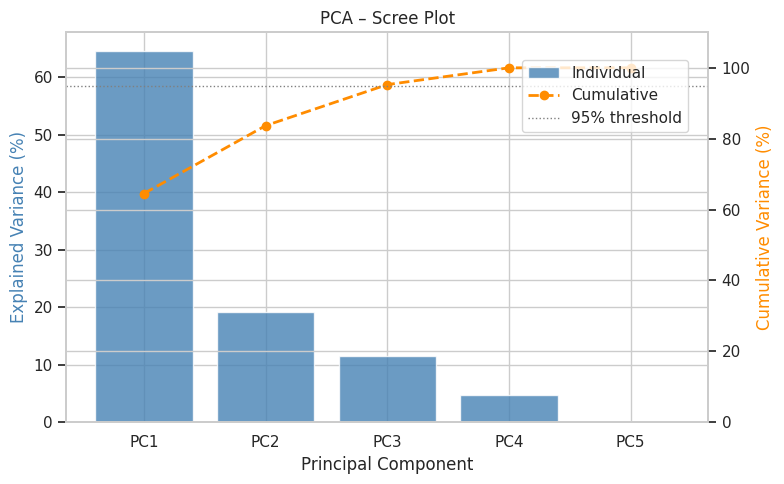

In [30]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(pca_summary['PC'], explained * 100, color='steelblue', alpha=0.8, label='Individual')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax1.set_xlabel('Principal Component')

ax2 = ax1.twinx()
ax2.plot(pca_summary['PC'], cumulative * 100, 'o--', color='darkorange', linewidth=2, label='Cumulative')
ax2.axhline(95, color='gray', linestyle=':', linewidth=1, label='95% threshold')
ax2.set_ylabel('Cumulative Variance (%)', color='darkorange')
ax2.set_ylim(0, 110)

plt.title('PCA – Scree Plot')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

#### PCA Loadings

In [32]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=num_features,
    columns=[f'PC{i+1}' for i in range(len(num_features))]
).round(4)

print(loadings)

                 PC1     PC2     PC3     PC4     PC5
NA_Sales      0.4768 -0.0403  0.6753 -0.0600 -0.5581
EU_Sales      0.4673  0.0715 -0.6028 -0.5821 -0.2727
JP_Sales     -0.1580  0.9778  0.0820 -0.0441 -0.1016
Other_Sales   0.4886  0.1342 -0.3330  0.7912 -0.0803
Global_Sales  0.5391  0.1386  0.2511 -0.1723  0.7729


### Task 5 – PCA Interpretation

| Component | Explained Variance | Cumulative |
|---|---|---|
| PC1 | 64.53% | 64.53% |
| PC2 | 19.14% | 83.68% |
| PC3 | 11.58% | 95.25% |
| PC4 | 4.74%  | 99.99% |
| PC5 | 0.01%  | 100.00% |

**PC1 (64.53%):** All sales columns load positively and similarly
(NA=0.48, EU=0.47, Other=0.49, Global=0.54), except JP which is low (-0.16).
PC1 represents **overall global sales volume**.

**PC2 (19.14%):** JP_Sales dominates with a loading of 0.98.
PC1 represents the **unique pattern of the Japanese market**,
which behaves very differently from Western markets.

**PC3 (11.58%):** Contrast between NA_Sales (0.68) and EU_Sales (-0.60).
Represents **NA vs EU regional difference**.

**Dimensionality Reduction Conclusion:**
- 3 components explain 95.25% of variance
- We can reduce from 5 features to 3 with minimal information loss
- PC5 contributes almost nothing (0.01%) and can be safely dropped